# AI Generated Text Detector: Model Training Pipeline

## 1. Environment Setup and Library Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 2. Dataset Loading and Exploratory Data Analysis

In [2]:
df = pd.read_csv('AI_Human.csv')
print(f'Total Samples: {df.shape[0]}')
print(f'Total Columns: {df.shape[1]}')
df.head()


Total Samples: 487235
Total Columns: 2


,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [3]:
# Check missing values and class distribution
print('Missing values:')
print(df.isnull().sum())

df = df.dropna().reset_index(drop=True)
df['generated'] = df['generated'].astype(int)

class_counts = df['generated'].value_counts()
print('\nClass counts:')
print(class_counts)


Missing values:
text         0
generated    0
dtype: int64

Class counts:
generated
0    305797
1    181438
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_33904\2528020115.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Human-written (0)', 'AI-generated (1)'], y=class_counts.values, palette='Blues_r')


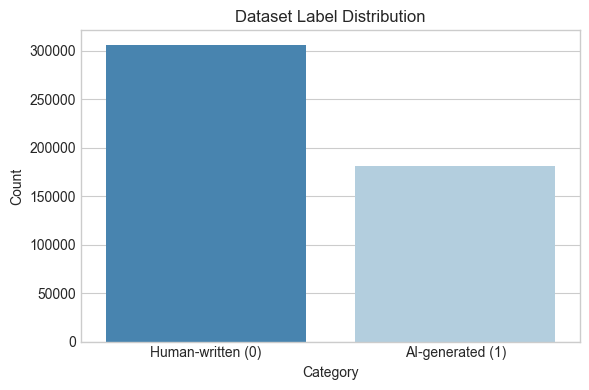

In [4]:
# Visualize label distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=['Human-written (0)', 'AI-generated (1)'], y=class_counts.values, palette='Blues_r')
plt.title('Dataset Label Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## 3. Data Preprocessing and Train-Test Split

In [5]:
# Stratified sampling for robust training and memory efficiency
sample_size = min(100000, len(df))
df_sampled, _ = train_test_split(df, train_size=sample_size, stratify=df['generated'], random_state=42)

X = df_sampled['text']
y = df_sampled['generated']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training Samples: {len(X_train)}')
print(f'Testing Samples: {len(X_test)}')


Training Samples: 80000
Testing Samples: 20000


## 4. Pipeline Construction and Feature Extraction

In [6]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        stop_words='english'
    )),
    ('classifier', LogisticRegression(
        C=5.0,
        max_iter=1000,
        random_state=42
    ))
])
print(pipeline)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                 stop_words='english', sublinear_tf=True)),
                ('classifier',
                 LogisticRegression(C=5.0, max_iter=1000, random_state=42))])


## 5. Model Training

In [7]:
pipeline.fit(X_train, y_train)
print('Training completed.')


Training completed.


## 6. Model Evaluation and Performance Metrics

In [8]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy:  {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall:    {recall * 100:.2f}%')
print(f'F1-Score:  {f1 * 100:.2f}%')
print(f'ROC-AUC:   {roc_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Human-written', 'AI-generated']))


Accuracy:  99.63%
Precision: 99.81%
Recall:    99.19%
F1-Score:  99.50%
ROC-AUC:   0.9998

Classification Report:
               precision    recall  f1-score   support

Human-written       1.00      1.00      1.00     12552
 AI-generated       1.00      0.99      1.00      7448

     accuracy                           1.00     20000
    macro avg       1.00      1.00      1.00     20000
 weighted avg       1.00      1.00      1.00     20000



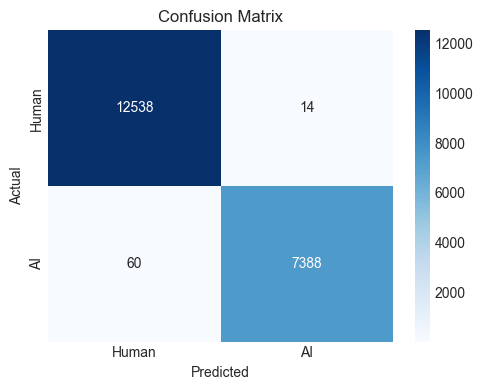

In [9]:
# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 7. Sample Inference Verification

In [10]:
test_samples = [
    'Cars have been around since they became famous in the 1900s. People drive them every day to commute to work and go to school.',
    'The socio-economic implications of automated transport infrastructure delineate a paradigm shift in urban logistics, optimizing resource allocation across macro-scale distribution networks.'
]

for sample in test_samples:
    pred = pipeline.predict([sample])[0]
    prob = pipeline.predict_proba([sample])[0]
    label = 'AI-generated' if pred == 1 else 'Human-written'
    confidence = prob[pred] * 100
    print(f'Text: {sample[:60]}...')
    print(f'Prediction: {label} ({confidence:.2f}% confidence)\n')


Text: Cars have been around since they became famous in the 1900s....
Prediction: Human-written (68.43% confidence)

Text: The socio-economic implications of automated transport infra...
Prediction: AI-generated (99.42% confidence)



## 8. Exporting the Pipeline

In [11]:
os.makedirs('models', exist_ok=True)
model_path = os.path.join('models', 'ai_text_classifier.joblib')
joblib.dump(pipeline, model_path)
print(f'Pipeline saved successfully to: {model_path}')


Pipeline saved successfully to: models\ai_text_classifier.joblib
